In [133]:
import pandas as pd
import geopandas as gp
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from datetime import datetime
import glob

In [134]:
file = '/Users/ryansponzilli/Developer/Python Projects/health-data/data/raw/apple_health/apple_health_export/workout-routes/route_2022-09-08_4.24pm.gpx'
gdf = gp.read_file(file, layer='track_points')
gdf = gdf[["time", "ele", "geometry"]]
gdf["time"] = pd.to_datetime(gdf["time"])
gdf = gdf.rename(columns={"time": "datetime", "ele": "elevation"})

In [135]:
gdf

,datetime,elevation,geometry
0,2022-09-08 20:08:17+00:00,232.041046,POINT (-88.27981 41.92868)
1,2022-09-08 20:08:18+00:00,232.037796,POINT (-88.27981 41.92869)
2,2022-09-08 20:08:19+00:00,232.029541,POINT (-88.27981 41.92872)
3,2022-09-08 20:08:20+00:00,232.023087,POINT (-88.27981 41.92875)
4,2022-09-08 20:08:21+00:00,232.015594,POINT (-88.27981 41.92877)
...,...,...,...
2788,2022-09-08 21:24:53+00:00,231.708603,POINT (-88.2798 41.92856)
2789,2022-09-08 21:24:54+00:00,231.746201,POINT (-88.27981 41.92854)
2790,2022-09-08 21:24:55+00:00,231.785324,POINT (-88.27982 41.92851)
2791,2022-09-08 21:24:56+00:00,231.825195,POINT (-88.27984 41.92848)


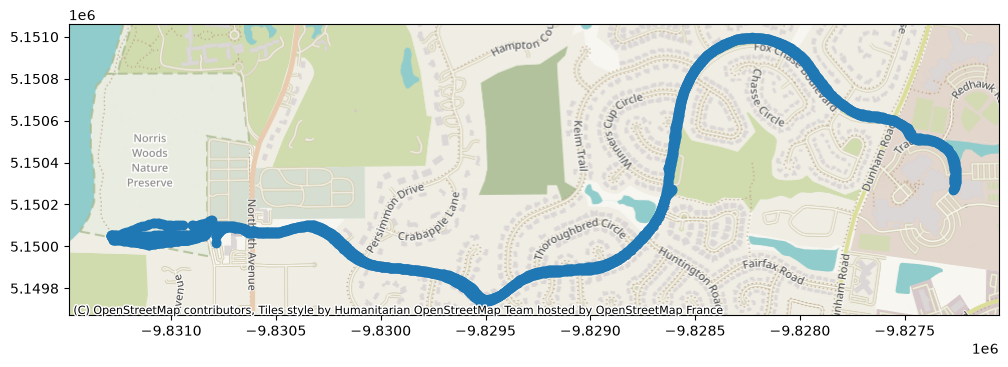

In [136]:
fig, ax = plt.subplots(figsize=(12, 5))

gdf.to_crs(3857).plot(ax=ax)
cx.add_basemap(ax)

Freshman Summer Training
Freshman XC Season
Freshman Winter Training
Freshman Track Season

In [137]:
MIN_DATE = datetime(2019, 6, 10)
MAX_DATE = datetime(2023, 5, 16)
seasons = pd.DataFrame([
    {"year": "Freshman", "season": "Summer Training", "start_date": datetime(2019, 6, 10), "end_date": datetime(2019, 8, 11)},
    {"year": "Freshman", "season": "XC Season", "start_date": datetime(2019, 8, 12), "end_date": datetime(2019, 11, 7)},
    {"year": "Freshman", "season": "Winter Training", "start_date": datetime(2019, 11, 23), "end_date": datetime(2020, 1, 26)},
    {"year": "Freshman", "season": "Track Season", "start_date": datetime(2020, 1, 27), "end_date": datetime(2020, 5, 1)},
    {"year": "Sophomore", "season": "Summer Training", "start_date": datetime(2020, 5, 26), "end_date": datetime(2020, 8, 9)},
    {"year": "Sophomore", "season": "XC Season", "start_date": datetime(2020, 8, 10), "end_date": datetime(2020, 10, 18)},
    {"year": "Sophomore", "season": "Winter Training", "start_date": datetime(2020, 11, 9), "end_date": datetime(2021, 4, 4)},
    {"year": "Sophomore", "season": "Track Season", "start_date": datetime(2021, 4, 5), "end_date": datetime(2021, 6, 9)},
    {"year": "Junior", "season": "Summer Training", "start_date": datetime(2021, 6, 28), "end_date": datetime(2021, 8, 8)},
    {"year": "Junior", "season": "XC Season", "start_date": datetime(2021, 8, 9), "end_date": datetime(2021, 10, 24)},
    {"year": "Junior", "season": "Winter Training", "start_date": datetime(2021, 11, 22), "end_date": datetime(2022, 1, 30)},
    {"year": "Junior", "season": "Track Season", "start_date": datetime(2022, 1, 31), "end_date": datetime(2022, 4, 27)},
    {"year": "Senior", "season": "Summer Training", "start_date": datetime(2022, 6, 13), "end_date": datetime(2022, 8, 7)},
    {"year": "Senior", "season": "XC Season", "start_date": datetime(2022, 8, 8), "end_date": datetime(2022, 11, 5)},
    {"year": "Senior", "season": "Winter Training", "start_date": datetime(2022, 12, 1), "end_date": datetime(2023, 1, 29)},
    {"year": "Senior", "season": "Track Season", "start_date": datetime(2023, 1, 30), "end_date": datetime(2023, 5, 16)},
])

def bucket_date(date):
    for i, row in seasons.iterrows():
        if (date >= row["start_date"]) & (date <= row["end_date"]):
            return row["year"], row["season"]
    return (None, None)

In [138]:
# load track files
path = '/Users/ryansponzilli/Developer/Python Projects/health-data/data/raw/apple_health/apple_health_export/workout-routes'
tracks = glob.glob(path + "/*")
track_datetimes = [datetime.strptime(t.split("/")[-1].removeprefix("route_").removesuffix(".gpx"), "%Y-%m-%d_%I.%M%p") for t in tracks]
# assemble dataframe
df_tracks = pd.DataFrame({"track_file": tracks, "track_file_date": track_datetimes})
df_tracks = df_tracks.loc[(df_tracks["track_file_date"] >= MIN_DATE) & (df_tracks["track_file_date"] <= MAX_DATE)].sort_values("track_file_date").reset_index(drop=True)
# bucket dates into seasons
df_tracks["year"] = df_tracks["track_file_date"].apply(lambda x: bucket_date(x)[0])
df_tracks["season"] = df_tracks["track_file_date"].apply(lambda x: bucket_date(x)[1])
df_tracks = df_tracks.dropna()

In [139]:
df_tracks

,track_file,track_file_date,year,season
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00,Freshman,Summer Training
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00,Freshman,Summer Training
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00,Freshman,Summer Training
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-14 14:56:00,Freshman,Summer Training
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-14 17:15:00,Freshman,Summer Training
...,...,...,...,...
1123,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:10:00,Senior,Track Season
1124,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:42:00,Senior,Track Season
1125,/Users/ryansponzilli/Developer/Python Projects...,2023-05-05 15:11:00,Senior,Track Season
1126,/Users/ryansponzilli/Developer/Python Projects...,2023-05-06 11:15:00,Senior,Track Season


In [140]:
def get_start_point(gpx_file):
    gdf = gp.read_file(file, layer='track_points')
    return gdf.iloc[0]["geometry"]

In [141]:
def in_stc(geom):
    STC_LAT_MIN = 41.866329
    STC_LAT_MAX = 41.951764
    STC_LON_MIN = -88.382261
    STC_LON_MAX = -88.240518
    lon = geom.coords[0][0]
    lat = geom.coords[0][1]
    
    return (lon >= STC_LON_MIN) & (lon <= STC_LON_MAX) & (lat >= STC_LAT_MIN) & (lat <= STC_LAT_MAX)

In [142]:
point_list = []
in_stc_list = []
for file in df_tracks["track_file"].to_list():
    point = get_start_point(df_tracks.iloc[0]["track_file"])
    point_list.append(point)
    in_stc_list.append(in_stc(point))

In [143]:
gdf_tracks = gp.GeoDataFrame(df_tracks, geometry=point_list, crs="EPSG:4326")
gdf_tracks["in_stc"] = in_stc_list
gdf_tracks

,track_file,track_file_date,year,season,geometry,in_stc
0,/Users/ryansponzilli/Developer/Python Projects...,2019-06-10 07:46:00,Freshman,Summer Training,POINT (-88.32154 41.91101),True
1,/Users/ryansponzilli/Developer/Python Projects...,2019-06-11 07:32:00,Freshman,Summer Training,POINT (-88.34764 41.928),True
2,/Users/ryansponzilli/Developer/Python Projects...,2019-06-12 07:35:00,Freshman,Summer Training,POINT (-88.32152 41.91252),True
3,/Users/ryansponzilli/Developer/Python Projects...,2019-06-14 14:56:00,Freshman,Summer Training,POINT (-88.28753 41.90455),True
4,/Users/ryansponzilli/Developer/Python Projects...,2019-06-14 17:15:00,Freshman,Summer Training,POINT (-88.27906 41.90787),True
...,...,...,...,...,...,...
1123,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:10:00,Senior,Track Season,POINT (-88.27989 41.92867),True
1124,/Users/ryansponzilli/Developer/Python Projects...,2023-05-04 15:42:00,Senior,Track Season,POINT (-88.27658 41.92845),True
1125,/Users/ryansponzilli/Developer/Python Projects...,2023-05-05 15:11:00,Senior,Track Season,POINT (-88.27988 41.92846),True
1126,/Users/ryansponzilli/Developer/Python Projects...,2023-05-06 11:15:00,Senior,Track Season,POINT (-88.32198 41.95005),True


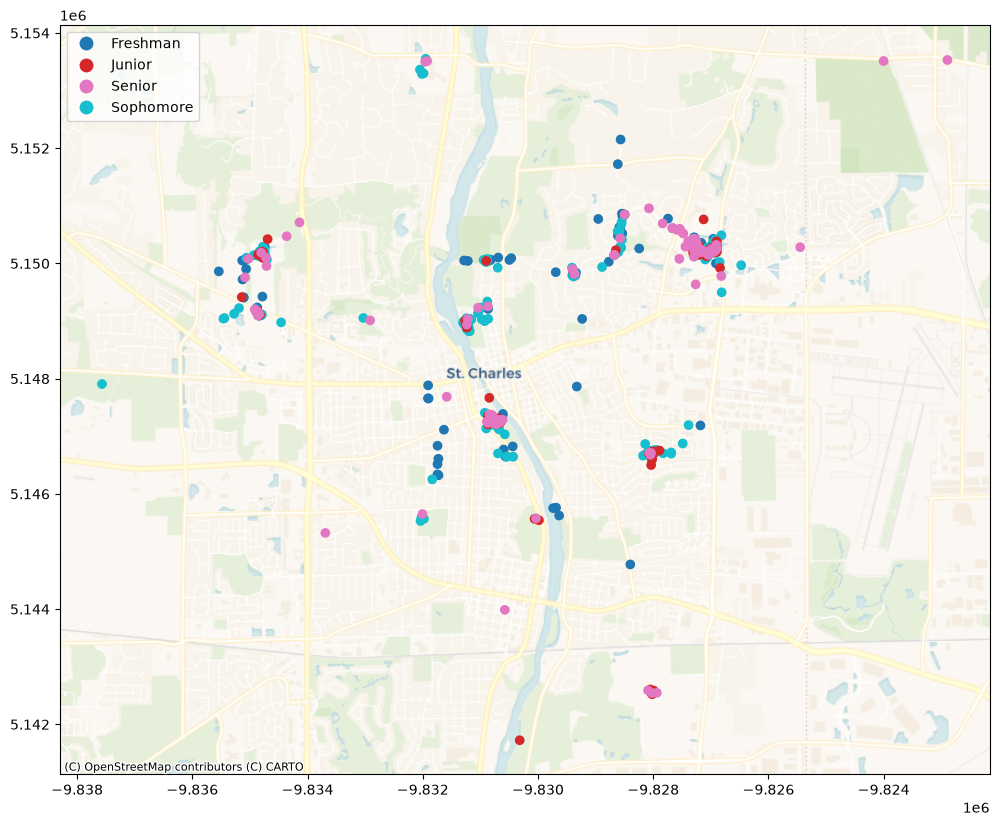

In [164]:
fig, ax = plt.subplots(figsize=(12, 12))

gdf_tracks.loc[gdf_tracks['in_stc']].to_crs(3857).plot("year", ax=ax, legend=True)
cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)